In [1]:
# Packages

import os
import sys
import obspy
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft, fftfreq, next_fast_len
from obspy.core import read, Trace
from obspy.core import Stream
from glob import glob
from obspy.signal import PPSD
from pathlib import Path
from datetime import datetime, timedelta
from scipy.signal import detrend


In [2]:
# Function definitions

# Simple spectrum calculation function
def plot_spectrum(tr):
    """Plot spectrum of ObsPy trace"""
    #tr.detrend('demean')
    #tr.taper(0.5, 'hann')   
    sr = tr.stats.sampling_rate
    nfft = next_fast_len(tr.stats.npts)  # pad data with zeros for fast FT
    pos_freq = (nfft + 1) // 2  # index for positive frequencies
    spec = fft(tr.data, nfft)[:pos_freq]
    freq = fftfreq(nfft, 1 / sr)[:pos_freq]  # get freqs of DFT bin
    return spec, freq


# Function for calculating mean and variance from histogram of spectra
# Supplied by Ethan Williams, 2/2026
def noise_stats(H,xm,ym):
    nx = len(xm)
    mn = np.zeros(nx)
    vr = mn.copy()
    for ix in range(nx):
        if np.sum(H[ix,:]) == 0:
            mn[ix] = np.nan
            vr[ix] = np.nan
        else:
            mn[ix] = np.average(ym,weights=H[ix,:])
            vr[ix] = np.average((ym-mn[ix])**2,weights=H[ix,:])
    return xm,mn,vr

# Load all data.

def Load_BADGER_traces(dayrange,hrrange,yrstr,sta,eqdays,SACstr):
    """Calculate noise spectrum for specified hours and Julian days"""
    n=0; neqks= 0
    for iday in range(0,len(dayrange)):
        if dayrange[iday]<10:
            daystr='00'+str(dayrange[iday])
        elif dayrange[iday]>=10 and dayrange[iday]<100:
            daystr='0'+str(dayrange[iday])
        else:
            daystr= str(dayrange[iday])
    
        dayname= yrstr+'.'+daystr
        if dayname in eqdays:
            eqflag= True
        else:
            eqflag= False
        
        skipflag=0
        #for ihr in range(0,11):
        for ihr in range(0,len(hrrange)):
            if hrrange[ihr]<10:
                hrstr= '0'+str(hrrange[ihr])
            else:
                hrstr= str(hrrange[ihr])
            
            
            fname='/Volumes/golos/'+SACstr+yrstr+'.'+daystr+'/XX.'+sta+'.'+yrstr+'.'+str(dayrange[iday])+'.'+hrstr+'.00.00.HHZ.SAC'# S, S4.
            fpath= Path(fname)
            if eqflag:
                neqks= neqks+1
            elif fpath.is_file()==False:
                print('Missing file skipped. '+fname)
                skipflag=1
            else:
                if ihr==0 or skipflag==1:
                    tr= read(fname, format='SAC')
                    tr[0].detrend('demean')
                    n=n+1
                    skipflag=0
                else:
                    tr += read(fname, format='SAC')
                    tr[ihr].detrend('demean')
                    n=n+1
            
        if eqflag==False:       
            tr.merge(fill_value='latest')
            if iday==0:
                tr_all= tr
            elif 'tr_all' not in locals():
                tr_all= tr
            else:    
                tr_all += tr

    print('Done reading files')
    
   
    return tr_all

In [10]:
# Calculate 24-hour winter spectrum for a single BADGER station
# Memory crashes when I loop through all stations, so this saves output for one station at a time. 
# Specify which station below in "sta"

# Load data
# Station-specific notes: 
#  BA05 had most data missing due to power loss in S3 (winter 2024). Don't calculate.
#  BA03 had clock resync disabled in S3 (winter 2024). Don't calculate.
#  BA04 had data gaps on day 2 (Jan 2, 2024) so dayrange must begin on day 3 
#  BA06 had issues on several days that are not addressed by length check, so uncomment dayrange.remove line below.

hrrange= range(0,24,2)
dayrange= list(range(2,92,1)) # In 2024, day 1 has Noto eq'k, so start on index 2.
# Uncomment following line for station BA06.
#dayrange.remove(81); dayrange.remove(79); dayrange.remove(77); dayrange.remove(33); dayrange.remove(25); dayrange.remove(24)

# Read datafile
eqdays= []
with open('/Users/golos/Research/ReceiverFunctions/RFcodes_Junlin/Data/Projects/BADGER/Datafiles_S3.txt','r') as file:
    for line in file:
        lf= len(line)
        if line[lf-7]=='Z':
            eqdays.append(line[22:30]) # Anything besides first servicing.
            #eqdays.append(line[19:27]) # For first servicing only because naming convention changes (use if you want to use winter 2023)

            
sta="BA110"; yrstr= "2024"
SACstr="SAC-S3/" # Change to refer to correct data directory
tr_all= Load_BADGER_traces(dayrange,hrrange,yrstr,sta,eqdays,SACstr)

# Put traces into 2d numpy array and remove days with data gaps.
data= tr_all
ntraces0=len(tr_all) # If you want to check how many days removed due to data gaps.
max_len = max(tr.stats.npts for tr in tr_all)
tr_all.traces = [tr for tr in tr_all if tr.stats.npts == max_len]
ntraces= len(tr_all) 
times= tr_all[0].times()
tracelist= [trace.data for trace in tr_all]
data= np.stack(tracelist,axis=1)
nt = data.shape[0] # number time steps.
nc= 1
fs= 200

# Calculate a PSD for all days at this station.
data *= np.tile(np.hamming(nt),(nc,1)).T
spec = np.fft.rfft(data,axis=0)
psd = (2/fs)*abs(spec)**2/np.sum(np.hamming(nt))
f = np.fft.rfftfreq(nt,d=1./fs)
print("PSD calculated")

# Construct a histogram of PSD
nx = 100
ny = 100
xbins = np.logspace(-2,2,nx)
ybins= np.linspace(0,9,ny)
nd= ntraces
H = np.zeros((nx-1,ny-1,nc))
dB = np.log10(psd)
H,xe,ye= np.histogram2d(f,dB[:,0],bins=(xbins,ybins))
print("Histogram finished")

# Statistics for histogram to make mean spectrum.
H /= nd
xm = (xe[1:] + xe[:-1])/2
ym = (ye[1:] + ye[:-1])/2
mean = np.zeros((nx-1,nc))
var = np.zeros((nx-1,nc))
_,mean,var = noise_stats(H,xm,ym)
std = np.sqrt(var)

# Save
odir='Noise/Spectra_new/'
xmsavename= sta+'_xm_W24h2.npy'
ymsavename= sta+'_ym_W24h2.npy'
meansavename= sta+'_mean_W24h2.npy'

np.save(os.path.join(odir,xmsavename),xm)
np.save(os.path.join(odir,ymsavename),ym)
np.save(os.path.join(odir,meansavename),mean)

Done reading files
PSD calculated
Histogram finished


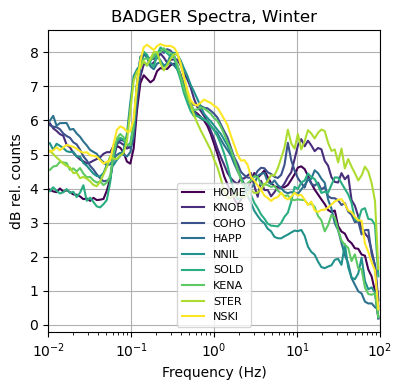

In [12]:
# Plot all, in a loop.

nchan=9
stalist=("BA09","BA01","BA02","BA110","BA04","BA07","BA08","BA06","BA10")
stanames= ("HOME","KNOB","COHO","HAPP","NNIL","SOLD","KENA","STER","NSKI")

cmap = plt.cm.viridis
colors = cmap(np.linspace(0,1,nchan))



fig = plt.figure(figsize=(4,4))
for k in range(nchan):
#for k in range(1,2):
    sta= stalist[k]
    xmsavename= "Noise/Spectra_new/"+sta+"_xm_W24h2.npy"; 
    meansavename= "Noise/Spectra_new/"+sta+"_mean_W24h2.npy";
    xm= np.load(xmsavename)
    mean= np.load(meansavename)
    plt.plot(xm,mean,color=colors[k],label=stanames[k])
    del xm, mean
plt.gca().set_xscale('log')
plt.xlabel('Frequency (Hz)')
plt.ylabel(r'dB rel. counts')
plt.title('BADGER Spectra, Winter')
plt.legend(loc='lower center',fontsize=8)
plt.grid('full')
plt.tight_layout()
plt.xlim(1e-2,1e2)
plt.savefig(os.path.join(odir,'Spectra_Winter_24hr.png'),dpi=150)


In [23]:
# Winter spectra, 8 hour (nighttime or daytime, can specify which) segments

# Load data
# Station-specific notes: 
#  BA05 had most data missing due to power loss in S3 (winter 2024). Don't calculate.
#  BA03 had clock resync disabled in S3 (winter 2024). Don't calculate.
#  BA04 had data gaps on day 2 (Jan 2, 2024) so dayrange must begin on day 3 
#  BA06 had issues on several days that are not addressed by length check, so uncomment dayrange.remove line below.


#hrrange= range(6,14,2) # Night
hrrange= range(16,24,2) # Day
dayrange= list(range(2,92,1)) # In 2024, day 1 (Jan 1, 2024) has Mw~7 Noto eq'k, so start on index 2.
#For BA06 ONLY: 
#dayrange.remove(81); dayrange.remove(79); dayrange.remove(77); dayrange.remove(33); dayrange.remove(25); dayrange.remove(24)

# Read datafile - contains event info for large earthquakes.
eqdays= []
with open('/Users/golos/Research/ReceiverFunctions/RFcodes_Junlin/Data/Projects/BADGER/Datafiles_S3.txt','r') as file:
    for line in file:
        lf= len(line)
        if line[lf-7]=='Z':
            eqdays.append(line[22:30]) # Anything besides first servicing.
            #eqdays.append(line[19:27]) # For first servicing only

# Specify station, year            
sta="BA110"; yrstr= "2024"
SACstr="SAC-S3/" # Change to refer to correct data directory
tr_all= Load_BADGER_traces(dayrange,hrrange,yrstr,sta,eqdays,SACstr)


# Put traces into 2d numpy array and remove days with data gaps.
data= tr_all
ntraces0=len(tr_all)
max_len = max(tr.stats.npts for tr in tr_all)
tr_all.traces = [tr for tr in tr_all if tr.stats.npts == max_len]
ntraces= len(tr_all)
times= tr_all[0].times()
tracelist= [trace.data for trace in tr_all]
data= np.stack(tracelist,axis=1)
nt = data.shape[0] # number time steps.
nc= 1
fs= 200

# Calculate a PSD for all days at this station.
data *= np.tile(np.hamming(nt),(nc,1)).T
spec = np.fft.rfft(data,axis=0)
psd = (2/fs)*abs(spec)**2/np.sum(np.hamming(nt))
f = np.fft.rfftfreq(nt,d=1./fs)
print("PSD calculated")

# Construct a histogram of PSD
nx = 100
ny = 100
xbins = np.logspace(-2,2,nx)
ybins= np.linspace(0,9,ny)
nd= ntraces
H = np.zeros((nx-1,ny-1,nc))
dB = np.log10(psd)
H,xe,ye= np.histogram2d(f,dB[:,0],bins=(xbins,ybins))
print("Histogram finished")


# Statistics for histogram to make mean spectrum.
H /= nd
xm = (xe[1:] + xe[:-1])/2
ym = (ye[1:] + ye[:-1])/2
mean = np.zeros((nx-1,nc))
var = np.zeros((nx-1,nc))
_,mean,var = noise_stats(H,xm,ym)
std = np.sqrt(var)

# Save
odir='Noise/Spectra_new/'
xmsavename= sta+'_xm_W8hday.npy'
ymsavename= sta+'_ym_W8hday.npy'
meansavename= sta+'_mean_W8hday.npy'

np.save(os.path.join(odir,xmsavename),xm)
np.save(os.path.join(odir,ymsavename),ym)
np.save(os.path.join(odir,meansavename),mean)

Done reading files
PSD calculated
Histogram finished


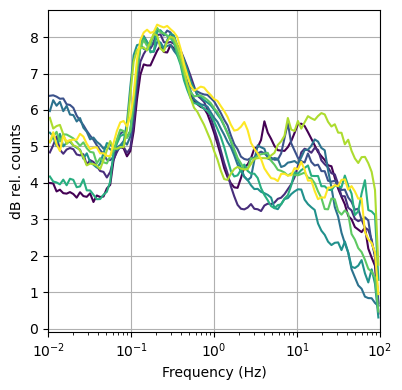

In [26]:
# Plot 8 hour winter spectra, all available stations.

nchan=9
stalist=("BA09","BA01","BA02","BA110","BA04","BA07","BA08","BA06","BA10")
stanames= ("HOME","KNOB","COHO","HAPP","NNIL","SOLD","KENA","STER","NSKI")

cmap = plt.cm.viridis
colors = cmap(np.linspace(0,1,nchan))



fig = plt.figure(figsize=(4,4))
for k in range(nchan):
#for k in range(1,2):
    sta= stalist[k]
    xmsavename= "Noise/Spectra_new/"+sta+"_xm_W8hday.npy"; 
    meansavename= "Noise/Spectra_new/"+sta+"_mean_W8hday.npy";
    xm= np.load(xmsavename)
    mean= np.load(meansavename)
    plt.plot(xm,mean,color=colors[k],label=stanames[k])
    del xm, mean
plt.gca().set_xscale('log')
plt.xlabel('Frequency (Hz)')
plt.ylabel(r'dB rel. counts')
#plt.title('BADGER Spectra, Winter')
#plt.legend(loc='lower center',fontsize=8)#plt.legend(loc='lower left')
plt.grid('full')
plt.tight_layout()
plt.xlim(1e-2,1e2)
plt.savefig(os.path.join(odir,'Spectra_Winter_8hr_day.png'),dpi=150)


In [44]:
# Summer, 24 hour spectra.

# Station-specific notes:
#  For BA08 (NNIL): day 155 has issues with huuuuuge amplitude on Z component. Add: dayrange.remove(155)
#  For BA09 (HOME): day 167 has similar issues on Z component. Add: dayrange.remove(167)

dayrange= list(range(153,244,1))
yrstr= "2024"; hrrange= range(0,24,2); SACstr= "SAC-S4/"
eqdays= []
with open('/Users/golos/Research/ReceiverFunctions/RFcodes_Junlin/Data/Projects/BADGER/Datafiles_S4.txt','r') as file:
    for line in file:
        lf= len(line)
        if line[lf-7]=='Z':
            eqdays.append(line[22:30]) # Anything besides first servicing.
            
sta="BA110"; yrstr= "2024"
#dayrange.remove(167)
SACstr="SAC-S4/" # Change to refer to correct data directory
tr_all= Load_BADGER_traces(dayrange,hrrange,yrstr,sta,eqdays,SACstr)



# Put traces into 2d numpy array and remove days with data gaps.
data= tr_all
ntraces0=len(tr_all)
max_len = max(tr.stats.npts for tr in tr_all)
tr_all.traces = [tr for tr in tr_all if tr.stats.npts == max_len]
ntraces= len(tr_all)
times= tr_all[0].times()
tracelist= [trace.data for trace in tr_all]
data= np.stack(tracelist,axis=1)
nt = data.shape[0] # number time steps.
nc= 1
fs= 200

# Calculate a PSD for all days at this station.
data *= np.tile(np.hamming(nt),(nc,1)).T
spec = np.fft.rfft(data,axis=0)
psd = (2/fs)*abs(spec)**2/np.sum(np.hamming(nt))
f = np.fft.rfftfreq(nt,d=1./fs)
print("PSD calculated")

# Construct a histogram of PSD
nx = 100
ny = 100
xbins = np.logspace(-2,2,nx)
ybins= np.linspace(0,8,ny)
nd= ntraces
H = np.zeros((nx-1,ny-1,nc))
dB = np.log10(psd)
H,xe,ye= np.histogram2d(f,dB[:,0],bins=(xbins,ybins))
print("Histogram finished")

# Statistics for histogram to make mean spectrum.
H /= nd
xm = (xe[1:] + xe[:-1])/2
ym = (ye[1:] + ye[:-1])/2
mean = np.zeros((nx-1,nc))
var = np.zeros((nx-1,nc))
_,mean,var = noise_stats(H,xm,ym)
std = np.sqrt(var)

# Save
odir='Noise/Spectra_new/'
xmsavename= sta+'_xm_S24h2.npy'
ymsavename= sta+'_ym_S24h2.npy'
meansavename= sta+'_mean_S24h2.npy'

np.save(os.path.join(odir,xmsavename),xm)
np.save(os.path.join(odir,ymsavename),ym)
np.save(os.path.join(odir,meansavename),mean)
            

Done reading files
PSD calculated
Histogram finished


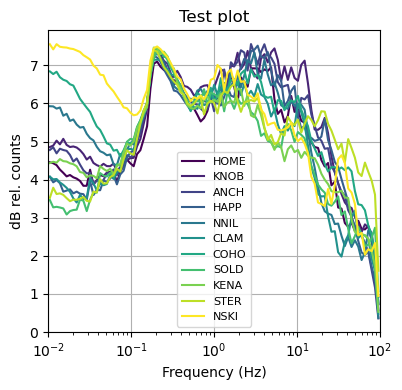

In [46]:
# Plot summer 24-hr spectra at all stations.

nchan=11
stalist=("BA09","BA01","BA05","BA110","BA04","BA03","BA02","BA07","BA08","BA06","BA10")
stanames= ("HOME","KNOB","ANCH","HAPP","NNIL","CLAM","COHO","SOLD","KENA","STER","NSKI")

cmap = plt.cm.viridis
colors = cmap(np.linspace(0,1,nchan))



fig = plt.figure(figsize=(4,4))
for k in range(nchan):
#for k in range(1,2):
    sta= stalist[k]
    xmsavename= "Noise/Spectra_new/"+sta+"_xm_S24h2.npy"; 
    meansavename= "Noise/Spectra_new/"+sta+"_mean_S24h2.npy";
    xm= np.load(xmsavename)
    mean= np.load(meansavename)
    plt.plot(xm,mean,color=colors[k],label=stanames[k])
    del xm, mean
plt.gca().set_xscale('log')
plt.xlabel('Frequency (Hz)')
plt.ylabel(r'dB rel. counts')
plt.title('Test plot')
plt.legend(loc='lower center',fontsize=8)
plt.grid('full')
plt.tight_layout()
plt.xlim(1e-2,1e2)
plt.savefig(os.path.join(odir,'Spectra_Summer_24h.png'),dpi=150)


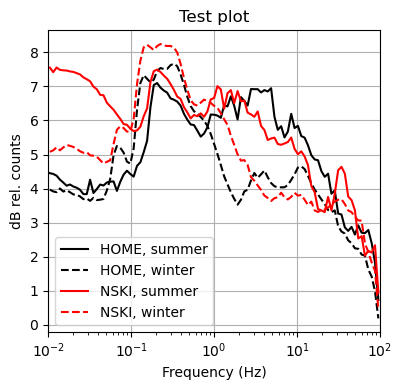

In [61]:
# Compare 24-hour spectra for 2 stations, winter vs. summer.


stalist=("BA09","BA10")
stanames= ("HOME","NSKI")


colorscomp=("k","r")


fig = plt.figure(figsize=(4,4))
for k in range(0,2):
    sta= stalist[k]
    xmsavenameS= "Noise/Spectra_new/"+sta+"_xm_S24h2.npy"; 
    meansavenameS= "Noise/Spectra_new/"+sta+"_mean_S24h2.npy";
    xmS= np.load(xmsavenameS); meanS= np.load(meansavenameS)
    xmsavenameW= "Noise/Spectra_new/"+sta+"_xm_W24h2.npy"; 
    meansavenameW= "Noise/Spectra_new/"+sta+"_mean_W24h2.npy";
    xmW= np.load(xmsavenameW); meanW= np.load(meansavenameW)
    plt.plot(xmS,meanS,color=colorscomp[k],label=stanames[k]+', summer')
    plt.plot(xmW,meanW,color=colorscomp[k],ls='--',label=stanames[k]+', winter')
    del xmS, meanS, xmW, meanW
plt.gca().set_xscale('log')
plt.xlabel('Frequency (Hz)')
plt.ylabel(r'dB rel. counts')
plt.title('Test plot')
plt.legend(loc='lower left')
plt.grid('full')
plt.tight_layout()
plt.xlim(1e-2,1e2)
plt.savefig(os.path.join(odir,'Spectra_24h_Summer_Winter_Comparison.png'),dpi=150)


In [58]:
# Summer - 8 hour nighttime time window
dayrange= list(range(153,244,1))

# Station-specific notes:
#  For BA08 (NNIL): day 155 has issues with huuuuuge amplitude on Z component. Add: dayrange.remove(155)
#  For BA09 (HOME): day 167 has similar issues on Z component. Add: dayrange.remove(167)
yrstr= "2024"; hrrange= range(16,24,2) #hrrange= range(6,14,2); 
SACstr= "SAC-S4/"
eqdays= []
with open('/Users/golos/Research/ReceiverFunctions/RFcodes_Junlin/Data/Projects/BADGER/Datafiles_S4.txt','r') as file:
    for line in file:
        lf= len(line)
        if line[lf-7]=='Z':
            eqdays.append(line[22:30]) # Anything besides first servicing.
            
sta="BA110"; 
#dayrange.remove(167)
tr_all= Load_BADGER_traces(dayrange,hrrange,yrstr,sta,eqdays,SACstr)

# Put traces into 2d numpy array and remove days with data gaps.
data= tr_all
ntraces0=len(tr_all)
max_len = max(tr.stats.npts for tr in tr_all)
tr_all.traces = [tr for tr in tr_all if tr.stats.npts == max_len]
ntraces= len(tr_all)
times= tr_all[0].times()
tracelist= [trace.data for trace in tr_all]
data= np.stack(tracelist,axis=1)
nt = data.shape[0] # number time steps.
nc= 1
fs= 200

# Calculate a PSD for all days at this station.
data *= np.tile(np.hamming(nt),(nc,1)).T
spec = np.fft.rfft(data,axis=0)
psd = (2/fs)*abs(spec)**2/np.sum(np.hamming(nt))
f = np.fft.rfftfreq(nt,d=1./fs)
print("PSD calculated")

# Construct a histogram of PSD
nx = 100
ny = 100
xbins = np.logspace(-2,2,nx)
ybins= np.linspace(0,8,ny)
nd= ntraces
H = np.zeros((nx-1,ny-1,nc))
dB = np.log10(psd)
H,xe,ye= np.histogram2d(f,dB[:,0],bins=(xbins,ybins))
print("Histogram finished")

# Statistics for histogram to make mean spectrum.
H /= nd
xm = (xe[1:] + xe[:-1])/2
ym = (ye[1:] + ye[:-1])/2
mean = np.zeros((nx-1,nc))
var = np.zeros((nx-1,nc))
_,mean,var = noise_stats(H,xm,ym)
std = np.sqrt(var)

# Save
odir='Noise/Spectra_new/'
xmsavename= sta+'_xm_S8hday.npy'
ymsavename= sta+'_ym_S8hday.npy'
meansavename= sta+'_mean_S8hday.npy'

np.save(os.path.join(odir,xmsavename),xm)
np.save(os.path.join(odir,ymsavename),ym)
np.save(os.path.join(odir,meansavename),mean)
            

Done reading files
PSD calculated
Histogram finished


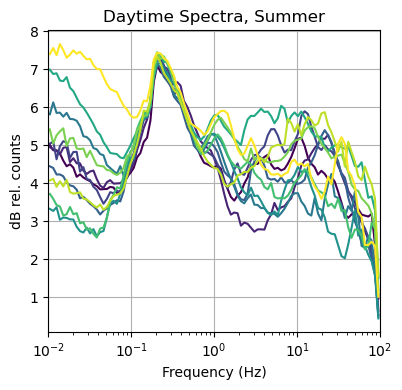

In [60]:
# Plot summer 8-hour spectra at all BADGER stations.

nchan=11
stalist=("BA09","BA01","BA05","BA110","BA04","BA03","BA02","BA07","BA08","BA06","BA10")
stanames= ("HOME","KNOB","ANCH","HAPP","NNIL","CLAM","COHO","SOLD","KENA","STER","NSKI")

cmap = plt.cm.viridis
colors = cmap(np.linspace(0,1,nchan))



fig = plt.figure(figsize=(4,4))
for k in range(nchan):
#for k in range(1,2):
    sta= stalist[k]
    xmsavename= "Noise/Spectra_new/"+sta+"_xm_S8hday.npy"; 
    meansavename= "Noise/Spectra_new/"+sta+"_mean_S8hday.npy";
    xm= np.load(xmsavename)
    mean= np.load(meansavename)
    plt.plot(xm,mean,color=colors[k],label=stanames[k])
    del xm, mean
plt.gca().set_xscale('log')
plt.xlabel('Frequency (Hz)')
plt.ylabel(r'dB rel. counts')
plt.title('Daytime Spectra, Summer')
#plt.legend(loc='lower center',fontsize=8)
plt.grid('full')
plt.tight_layout()
plt.xlim(1e-2,1e2)
plt.savefig(os.path.join(odir,'Spectra_Summer_day_nolegend.png'),dpi=150)

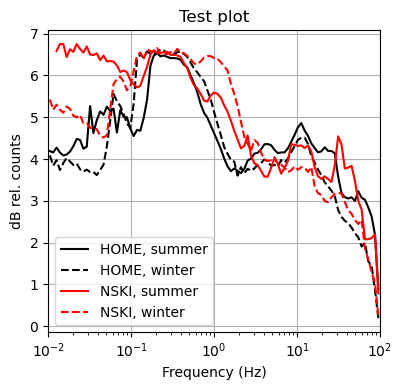

In [87]:
# Compare 2 stations, winter vs. summer, 8-hour spectra.

nchan=9
stalist=("BA09","BA10")
stanames= ("HOME","NSKI")


colorscomp=("k","r")


fig = plt.figure(figsize=(4,4))
for k in range(0,2):
    sta= stalist[k]
    xmsavenameS= "Noise/Spectra_new/"+sta+"_xm_S8h.npy"; 
    meansavenameS= "Noise/Spectra_new/"+sta+"_mean_S8h.npy";
    xmS= np.load(xmsavenameS); meanS= np.load(meansavenameS)
    xmsavenameW= "Noise/Spectra_new/"+sta+"_xm_W8h.npy"; 
    meansavenameW= "Noise/Spectra_new/"+sta+"_mean_W8h.npy";
    xmW= np.load(xmsavenameW); meanW= np.load(meansavenameW)
    plt.plot(xmS,meanS,color=colorscomp[k],label=stanames[k]+', summer')
    plt.plot(xmW,meanW,color=colorscomp[k],ls='--',label=stanames[k]+', winter')
    del xmS, meanS, xmW, meanW
plt.gca().set_xscale('log')
plt.xlabel('Frequency (Hz)')
plt.ylabel(r'dB rel. counts')
plt.title('Test plot')
plt.legend(loc='lower left')
plt.grid('full')
plt.tight_layout()
plt.xlim(1e-2,1e2)
plt.savefig(os.path.join(odir,'Spectra_8h_Summer_Winter_Comparison.png'),dpi=150)
